# 07 - Citeseer
Powtórzenie wszystkich eksperymentów na drugim datasecie.
Cel: sprawdzenie czy wnioski z Cory są ogólne i nie specyficzne dla jednego grafu.

In [1]:
import os, json
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv, GATConv, SAGEConv, APPNP

os.makedirs('../models/citeseer', exist_ok=True)
os.makedirs('../results', exist_ok=True)

dataset = Planetoid(root='../data/Citeseer', name='Citeseer')
data = dataset[0]
original_train_mask = data.train_mask.clone()

print('=== Citeseer ===')
print(f'Węzły:     {data.num_nodes}')
print(f'Krawędzie: {data.num_edges}')
print(f'Cechy:     {data.num_node_features}')
print(f'Klasy:     {dataset.num_classes}')
print(f'Train:     {data.train_mask.sum().item()}')
print(f'Test:      {data.test_mask.sum().item()}')

=== Citeseer ===
Węzły:     3327
Krawędzie: 9104
Cechy:     3703
Klasy:     6
Train:     120
Test:      1000


## Cora vs Citeseer

In [2]:
print(f'{"Dataset":<12} {"Węzły":>8} {"Krawędzie":>12} {"Cechy":>8} {"Klasy":>7}')
print('-' * 52)
print(f'{"Cora":<12} {"2708":>8} {"5429":>12} {"1433":>8} {"7":>7}')
print(f'{"Citeseer":<12} {data.num_nodes:>8} {data.num_edges:>12} {data.num_node_features:>8} {dataset.num_classes:>7}')

Dataset         Węzły    Krawędzie    Cechy   Klasy
----------------------------------------------------
Cora             2708         5429     1433       7
Citeseer         3327         9104     3703       6


## Wyniki z Cora

In [3]:
with open('../models/all_results.json') as f:
    cora_results = {
        name: {float(k): v for k, v in res.items()}
        for name, res in json.load(f).items()
        if name != 'MLP'
    }

ratios = [0.05, 0.10, 0.20]
seeds  = [42, 123, 456, 789, 1000]
labels = ['5%', '10%', '20%']

print('Wyniki Cora wczytane:')
print(f'{"Model":<12} {"5%":>14} {"10%":>14} {"20%":>14}')
print('-' * 58)
for name, res in cora_results.items():
    row = f'{name:<12}'
    for ratio in ratios:
        row += f'  {np.mean(res[ratio]):.4f}±{np.std(res[ratio]):.4f}'
    print(row)

Wyniki Cora wczytane:
Model                    5%            10%            20%
----------------------------------------------------------
GCN           0.7922±0.0147  0.8152±0.0143  0.8274±0.0147
GAT           0.8058±0.0090  0.8208±0.0087  0.8448±0.0102
GraphSAGE     0.7952±0.0118  0.8218±0.0105  0.8424±0.0156
APPNP         0.8216±0.0101  0.8392±0.0126  0.8550±0.0113


## Architektury modeli i funkcje pomocnicze

In [4]:
class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

class GAT(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=8):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels, heads=heads, dropout=0.6)
        self.conv2 = GATConv(hidden_channels * heads, out_channels, heads=1, dropout=0.6)

    def forward(self, x, edge_index):
        x = F.dropout(x, p=0.6, training=self.training)
        x = self.conv1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=0.6, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

class GraphSAGE(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

class APPNPNet(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels,
                 K=10, alpha=0.1, dropout=0.5):
        super().__init__()
        self.fc1  = torch.nn.Linear(in_channels, hidden_channels)
        self.fc2  = torch.nn.Linear(hidden_channels, out_channels)
        self.prop = APPNP(K=K, alpha=alpha)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.fc1(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.fc2(x)
        x = self.prop(x, edge_index)
        return F.log_softmax(x, dim=1)

MODELS = {
    'GCN': (GCN, {'in_channels': dataset.num_features, 'hidden_channels': 64, 'out_channels': dataset.num_classes}),
    'GAT': (GAT, {'in_channels': dataset.num_features, 'hidden_channels': 8,  'out_channels': dataset.num_classes}),
    'GraphSAGE': (GraphSAGE, {'in_channels': dataset.num_features, 'hidden_channels': 64, 'out_channels': dataset.num_classes}),
    'APPNP': (APPNPNet, {'in_channels': dataset.num_features, 'hidden_channels': 64, 'out_channels': dataset.num_classes, 'K': 10, 'alpha': 0.1}),
}
OPTIMIZERS = {
    'GCN': {'lr': 0.01},
    'GAT': {'lr': 0.005, 'weight_decay': 5e-4},
    'GraphSAGE': {'lr': 0.01,  'weight_decay': 5e-4},
    'APPNP': {'lr': 0.01,  'weight_decay': 5e-4},
}

def create_split(data, label_ratio, seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    available_indices = (~data.test_mask).nonzero(as_tuple=True)[0]
    train_size = int(data.num_nodes * label_ratio)
    shuffled = available_indices[torch.randperm(len(available_indices))]
    train_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
    train_mask[shuffled[:train_size]] = True
    return train_mask

def train(model, optimizer):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

def test(model):
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)
    acc = (pred[data.test_mask] == data.y[data.test_mask]).float().mean()
    return acc.item()

## Baseline - standardowy split

In [5]:
data.train_mask = original_train_mask
baselines = {}

for model_name, (ModelClass, model_kwargs) in MODELS.items():
    model = ModelClass(**model_kwargs)
    optimizer = torch.optim.Adam(model.parameters(), **OPTIMIZERS[model_name])

    for epoch in range(200):
        train(model, optimizer)

    acc = test(model)
    baselines[model_name] = acc
    print(f'{model_name:<12}: {acc:.4f}')

print('\nCiteseer:')
print('GCN 0.708 (Kipf & Welling 2017)')
print('GAT 0.725 (Veličković 2018)')
print('APPNP 0.717 (Gasteiger 2019)')

GCN         : 0.6550
GAT         : 0.6740
GraphSAGE   : 0.6940
APPNP       : 0.6870

Citeseer:
GCN 0.708 (Kipf & Welling 2017)
GAT 0.725 (Veličković 2018)
APPNP 0.717 (Gasteiger 2019)


## Eksperymenty - accuracy vs liczba etykiet

In [6]:
citeseer_results = {name: defaultdict(list) for name in MODELS}
best_accs = {name: 0 for name in MODELS}

for model_name, (ModelClass, model_kwargs) in MODELS.items():
    print(f'\n=== {model_name} ===')
    for ratio in ratios:
        for seed in seeds:
            data.train_mask = create_split(data, ratio, seed)

            model = ModelClass(**model_kwargs)
            optimizer = torch.optim.Adam(
                model.parameters(), **OPTIMIZERS[model_name])

            for epoch in range(200):
                train(model, optimizer)

            acc = test(model)
            citeseer_results[model_name][ratio].append(acc)
            print(f'  Ratio: {ratio:.0%}, Seed: {seed}, Acc: {acc:.4f}')

            if acc > best_accs[model_name]:
                best_accs[model_name] = acc
                torch.save(model.state_dict(),
                           f'../models/citeseer/{model_name.lower()}_best.pt')

data.train_mask = original_train_mask

print('\n--- Podsumowanie Citeseer ---')
print(f'{"Model":<12} {"5%":>14} {"10%":>14} {"20%":>14}')
print('-' * 58)
for name in MODELS:
    row = f'{name:<12}'
    for ratio in ratios:
        accs = citeseer_results[name][ratio]
        row += f'  {np.mean(accs):.4f}±{np.std(accs):.4f}'
    print(row)


=== GCN ===
  Ratio: 5%, Seed: 42, Acc: 0.6430
  Ratio: 5%, Seed: 123, Acc: 0.6620
  Ratio: 5%, Seed: 456, Acc: 0.6750
  Ratio: 5%, Seed: 789, Acc: 0.6940
  Ratio: 5%, Seed: 1000, Acc: 0.6990
  Ratio: 10%, Seed: 42, Acc: 0.6800
  Ratio: 10%, Seed: 123, Acc: 0.6780
  Ratio: 10%, Seed: 456, Acc: 0.6940
  Ratio: 10%, Seed: 789, Acc: 0.6750
  Ratio: 10%, Seed: 1000, Acc: 0.7230
  Ratio: 20%, Seed: 42, Acc: 0.6700
  Ratio: 20%, Seed: 123, Acc: 0.6890
  Ratio: 20%, Seed: 456, Acc: 0.7070
  Ratio: 20%, Seed: 789, Acc: 0.6890
  Ratio: 20%, Seed: 1000, Acc: 0.7080

=== GAT ===
  Ratio: 5%, Seed: 42, Acc: 0.6750
  Ratio: 5%, Seed: 123, Acc: 0.6740
  Ratio: 5%, Seed: 456, Acc: 0.6820
  Ratio: 5%, Seed: 789, Acc: 0.7040
  Ratio: 5%, Seed: 1000, Acc: 0.7150
  Ratio: 10%, Seed: 42, Acc: 0.6920
  Ratio: 10%, Seed: 123, Acc: 0.7120
  Ratio: 10%, Seed: 456, Acc: 0.7170
  Ratio: 10%, Seed: 789, Acc: 0.7060
  Ratio: 10%, Seed: 1000, Acc: 0.7260
  Ratio: 20%, Seed: 42, Acc: 0.7130
  Ratio: 20%, Seed: 123

## Porównanie Cora vs Citeseer

In [7]:
for ratio in ratios:
    print(f'\n--- {ratio:.0%} etykiet ---')
    print(f'{"Model":<12} {"Cora":>10} {"Citeseer":>10} {"Różnica":>10}')
    print('-' * 45)
    for name in MODELS:
        cora_acc     = np.mean(cora_results[name][ratio])
        citeseer_acc = np.mean(citeseer_results[name][ratio])
        diff = citeseer_acc - cora_acc
        sign = '+' if diff >= 0 else ''
        print(f'{name:<12} {cora_acc:>10.4f} {citeseer_acc:>10.4f} {sign}{diff:>9.4f}')


--- 5% etykiet ---
Model              Cora   Citeseer    Różnica
---------------------------------------------
GCN              0.7922     0.6746   -0.1176
GAT              0.8058     0.6900   -0.1158
GraphSAGE        0.7952     0.7012   -0.0940
APPNP            0.8216     0.6902   -0.1314

--- 10% etykiet ---
Model              Cora   Citeseer    Różnica
---------------------------------------------
GCN              0.8152     0.6900   -0.1252
GAT              0.8208     0.7106   -0.1102
GraphSAGE        0.8218     0.7182   -0.1036
APPNP            0.8392     0.7056   -0.1336

--- 20% etykiet ---
Model              Cora   Citeseer    Różnica
---------------------------------------------
GCN              0.8274     0.6926   -0.1348
GAT              0.8448     0.7292   -0.1156
GraphSAGE        0.8424     0.7352   -0.1072
APPNP            0.8550     0.7202   -0.1348


## Wizualizacja

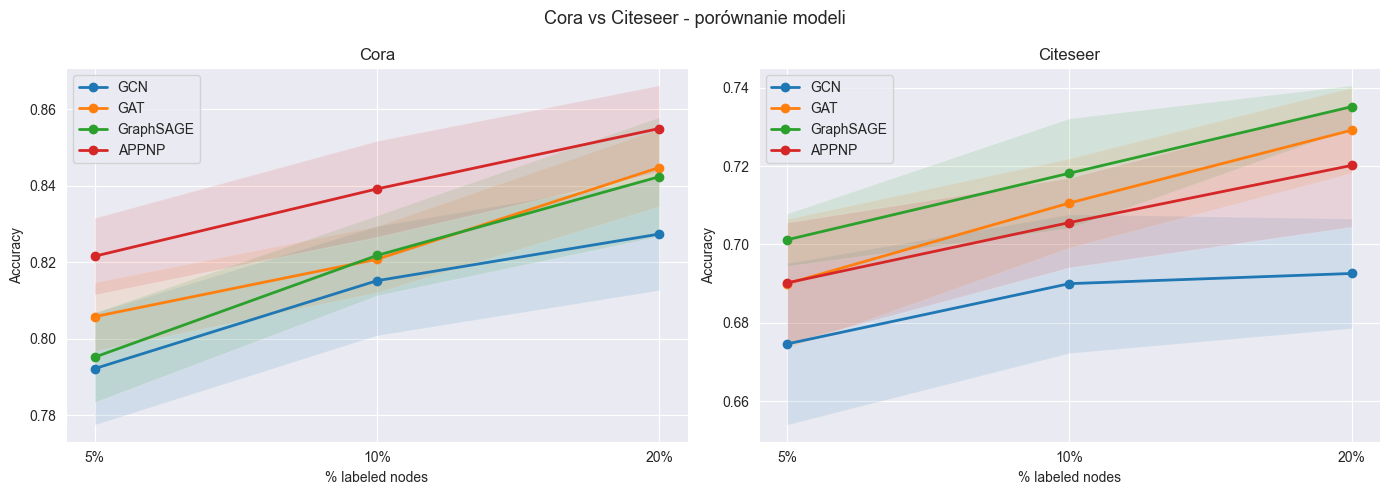

Wykres zapisany: ../results/cora_vs_citeseer.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, (dataset_name, results) in zip(axes, [
    ('Cora',     cora_results),
    ('Citeseer', {n: dict(r) for n, r in citeseer_results.items()})
]):
    for name in MODELS:
        means = [np.mean(results[name][r]) for r in ratios]
        stds  = [np.std(results[name][r])  for r in ratios]
        ax.plot(labels, means,
                marker='o',
                linewidth=2, label=name)
        ax.fill_between(labels,
                        [m - s for m, s in zip(means, stds)],
                        [m + s for m, s in zip(means, stds)],
                        alpha=0.12)
    ax.set_title(dataset_name)
    ax.set_xlabel('% labeled nodes')
    ax.set_ylabel('Accuracy')
    ax.legend()

plt.suptitle('Cora vs Citeseer - porównanie modeli', fontsize=13)
plt.tight_layout()
plt.savefig('../results/cora_vs_citeseer.png')
plt.show()
print('Wykres zapisany: ../results/cora_vs_citeseer.png')

## Zapis

In [9]:
citeseer_serializable = {
    name: {str(k): v for k, v in res.items()}
    for name, res in citeseer_results.items()
}
with open('../models/citeseer_results.json', 'w') as f:
    json.dump(citeseer_serializable, f, indent=2)

print('Zapisano:')
print('../models/citeseer_results.json')
print('../models/citeseer/*_best.pt')
print('../results/cora_vs_citeseer.png')

Zapisano:
../models/citeseer_results.json
../models/citeseer/*_best.pt
../results/cora_vs_citeseer.png
